# Name : Ubaid Ur Rehman
# Lab : 04  (Q_Learning)
# Date : 26/01/2026

### Question 1 

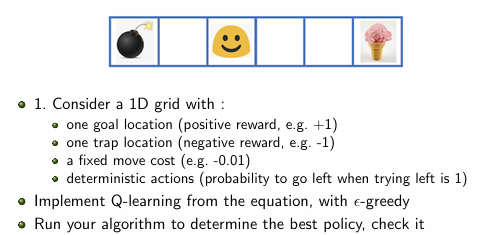

### Helping material : https://medium.com/@goldengrisha/a-beginners-guide-to-q-learning-understanding-with-a-simple-gridworld-example-2b6736e7e2c9

# My Contribution in this notebook:
So with the help of helping material , I understand the whole concept of Qlearning correctly then , I applied changes from 2d grid to 1d array.
Changes in ` reward grid initialization` , apply changes in `step method`, choose action, `initialization q_table` and at the last with using diffrent parameters like `alpha, gamma` we plot the graph.

In [18]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Helping material : https://medium.com/@goldengrisha/a-beginners-guide-to-q-learning-understanding-with-a-simple-gridworld-example-2b6736e7e2c9
# Define the gridworld environment
class GridWorld:
    def __init__(self):
        # this grid for reward
        # -1 for trap at index 0, +1 for goal at index 5
        self.grid = np.array([-1, 0, 0, 0, 0, 1]) 
        self.start_state = 2
        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def is_terminal(self, state):
        return self.grid[state] == 1 or self.grid[state] == -1

    def step(self, action):
        # deterministic actions
        if action == 0:  # Move right
            next_state = min(5, self.state + 1)
        elif action == 1:  # Move left
            next_state = max(0, self.state - 1)
        
        # calculate reward
        if self.is_terminal(next_state):
            reward = self.grid[next_state]
        else:
            reward = -0.01 # fixed move cost
            
        self.state = next_state
        done = self.is_terminal(next_state)
        
        return next_state, reward, done

In [19]:
class QLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.9, exploration_rate=0.1):
        # Q-values for each state-action pair (6 states, 2 actions)
        self.q_table = np.zeros((6, 2)) 
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

    def choose_action(self, state):
        if random.uniform(0, 1) < self.exploration_rate:
            return random.randint(0, 1) # Explore only two action randomly 
        else:
            return np.argmax(self.q_table[state]) # Exploit

    def update_q_value(self, state, action, reward, next_state):
        max_future_q = np.max(self.q_table[next_state]) # Best Q-value for next state
        current_q = self.q_table[state][action]
        
        # Q-learning formula
        self.q_table[state][action] = current_q + self.learning_rate * (
            reward + self.discount_factor * max_future_q - current_q
        )

In [20]:
# Function to run experiment for plotting
def run_experiment(alpha, gamma, episodes=500):
    env = GridWorld()
    agent = QLearningAgent(learning_rate=alpha, discount_factor=gamma)
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset() # Reset the environment at the start of each episode
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state) # Choose an action
            next_state, reward, done = env.step(action) # Take the action
            agent.update_q_value(state, action, reward, next_state) # Update Q-values
            state = next_state
            total_reward += reward
            
        rewards_per_episode.append(total_reward)
    return rewards_per_episode

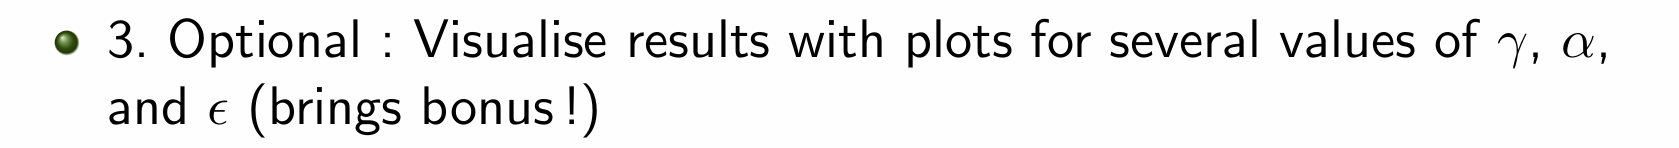


In [ ]:
# 
def plot_visualize(params):
    plt.figure(figsize=(10, 6))

    for alpha, gamma in params:
        rewards = run_experiment(alpha, gamma)
        # moving average for smoother plot
        smoothed_rewards = np.convolve(rewards, np.ones(20)/20, mode='valid')
        plt.plot(smoothed_rewards, label=f'α={alpha}, γ={gamma}')



    plt.xlabel('Episodes')
    plt.ylabel('Total Reward (Smoothed)')
    plt.title('Q-Learning Performance on  GridWorld')
    plt.legend()
    plt.grid(True)
    plt.show()



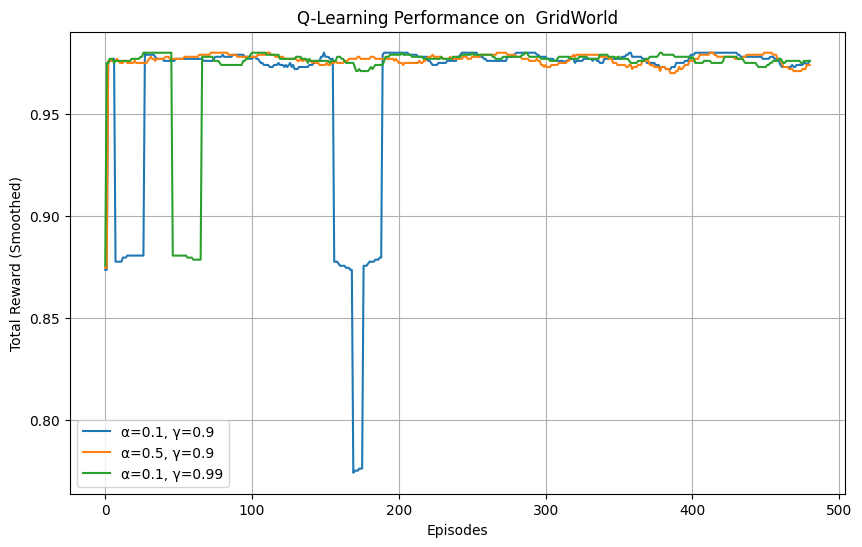

In [22]:
# Run and Visualise

# Define parameters to test
params = [
    (0.1, 0.9),   # alpha=0.1, gamma=0.9
    (0.5, 0.9),   # alpha=0.5, gamma=0.9
    (0.1, 0.99)   # alpha=0.1, gamma=0.99
]
plot_visualize(params)

# Question 2
##  TicTacToe with Q Learning

## Helping material: https://medium.com/@ardra4/tic-tac-toe-using-q-learning-a-reinforcement-learning-approach-d606cfdd64a3
# My Contribution:
 I adapted the GridWorld class structure from Question 1 to work for TicTacToe. 

 I implemented the game logic (win check, draw check) inside the 'step' function 

 and modified the state representation to handle the 3x3 board as a 1D array index 
 
 so the Q-Learning Agent could learn the game policies.

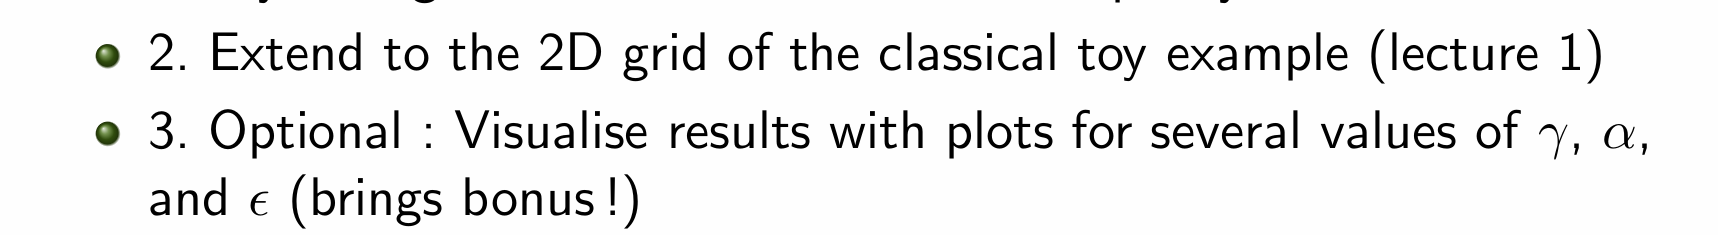

## Define the TicTacToe environment

In [29]:
class TicTacToe:
    def __init__(self):
        # 0 = empty, 1 = Agent (X), 2 = Opponent (O)
        self.board = np.zeros(9, dtype=int)
        self.start_state = 0 # base-3 index of empty board
        self.state = self.start_state

    def reset(self):
        self.board = np.zeros(9, dtype=int)
        self.state = self._get_state_index(self.board)
        return self.state

    # Helper to convert board (tuple) to unique integer index for Q-table
    def _get_state_index(self, board):
        # Interpret board as a base-3 number
        idx = 0
        for val in board:
            idx = 3 * idx + val
        return idx

    # Check for winner (returns 1 for Agent, 2 for Opponent, 0 for None, -1 for Draw)
    def check_winner(self, board):
        winning_combos = [
            [0, 1, 2], [3, 4, 5], [6, 7, 8], # Rows
            [0, 3, 6], [1, 4, 7], [2, 5, 8], # Cols
            [0, 4, 8], [2, 4, 6]             # Diagonals
        ]
        for combo in winning_combos:
            if board[combo[0]] == board[combo[1]] == board[combo[2]] and board[combo[0]] != 0:
                return board[combo[0]]
        
        if 0 not in board:
            return -1 # Draw
        return 0 # Continue

    def step(self, action):
        # Reconstruct board from current index (optional, but easier to just keep self.board)
        # Check validity
        if self.board[action] != 0:
            # Illegal move penalty
            return self.state, -10, True 

        # 1. Agent Move
        self.board[action] = 1
        
        winner = self.check_winner(self.board)
        
        if winner == 1: # Agent won
            return self._get_state_index(self.board), 10, True
        elif winner == -1: # Draw
            return self._get_state_index(self.board), 0, True

        # 2. Opponent Move (Environment logic)
        # Find empty spots
        empty_indices = [i for i, x in enumerate(self.board) if x == 0]
        opponent_action = random.choice(empty_indices)
        self.board[opponent_action] = 2

        winner = self.check_winner(self.board)
        next_state_idx = self._get_state_index(self.board)

        if winner == 2: # Opponent won (Agent lost)
            return next_state_idx, -10, True
        elif winner == -1: # Draw
            return next_state_idx, 0, True
            
        # Game continues
        self.state = next_state_idx
        return next_state_idx, -0.1, False # Small cost to encourage speed

In [30]:
class QLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.9, exploration_rate=0.1):
        # State space: 3^9 = 19683 states. Actions: 9 positions.
        self.q_table = np.zeros((19683, 9)) 
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

    def choose_action(self, state):
        if random.uniform(0, 1) < self.exploration_rate:
            return random.randint(0, 8) # Explore
        else:
            return np.argmax(self.q_table[state]) # Exploit

    def update_q_value(self, state, action, reward, next_state):
        max_future_q = np.max(self.q_table[next_state]) # Best Q-value for next state
        current_q = self.q_table[state][action]
        # Q-learning formula
        self.q_table[state][action] = current_q + self.learning_rate * (
            reward + self.discount_factor * max_future_q - current_q
        )

In [31]:
# Function to run experiment for plotting
def run_experiment(alpha, gamma, episodes=1000): # Increased episodes for training
    env = TicTacToe()
    agent = QLearningAgent(learning_rate=alpha, discount_factor=gamma)
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset() # Reset the environment
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state) 
            next_state, reward, done = env.step(action) 
            agent.update_q_value(state, action, reward, next_state) 
            state = next_state
            total_reward += reward
            
        rewards_per_episode.append(total_reward)
    return rewards_per_episode

In [32]:
# Visualization function
def plot_visualize(params):
    plt.figure(figsize=(10, 6))

    for alpha, gamma in params:
        rewards = run_experiment(alpha, gamma, episodes=2000) # More episodes for TicTacToe
        # Larger moving average window because game results are noisy
        smoothed_rewards = np.convolve(rewards, np.ones(50)/50, mode='valid')
        plt.plot(smoothed_rewards, label=f'α={alpha}, γ={gamma}')

    plt.xlabel('Episodes')
    plt.ylabel('Total Reward (Smoothed)')
    plt.title('Q-Learning Performance on TicTacToe')
    plt.legend()
    plt.grid(True)
    plt.show()



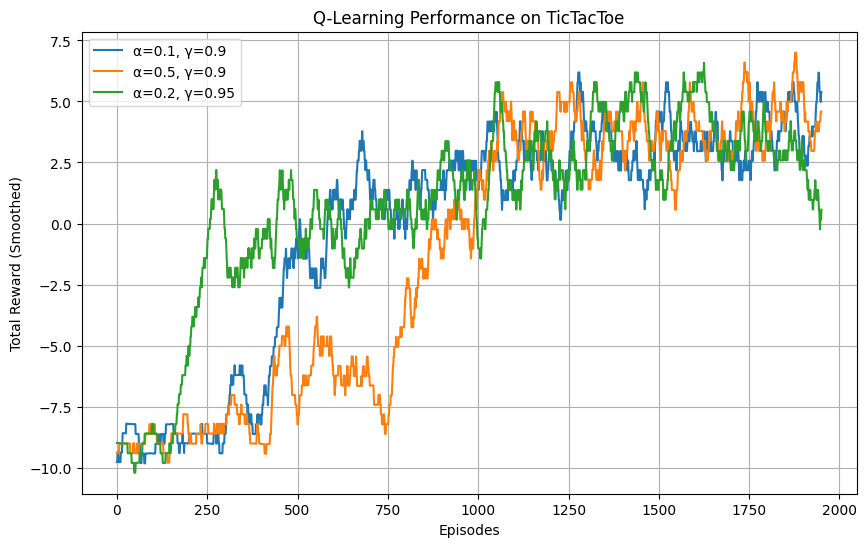

In [33]:
# Run and Visualise

# Define parameters to test
params = [
    (0.1, 0.9),   # alpha=0.1, gamma=0.9
    (0.5, 0.9),   # alpha=0.5, gamma=0.9
    (0.2, 0.95)   # alpha=0.2, gamma=0.95
]

plot_visualize(params)

### Conclusion

In the 1D GridWorld experiment, the agent demonstrated rapid learning due to the small state space (6 states), achieving near-optimal performance within the first **20 episodes**. The maximum average reward stabilized at approximately **0.98**, reflecting the consistent path to the goal (+1) minus step costs. Notably, the agent with **$\alpha=0.5$** maintained the highest stability, whereas the **$\alpha=0.1$** agent experienced a significant drop to a reward of **~0.78** around episode 170 before recovering, illustrating how lower learning rates can sometimes lead to temporary instability in simple deterministic environments.

In contrast, the TicTacToe experiment highlighted the complexity of a larger state space (~19,683 states). The agents initially struggled significantly, stuck in a "losing phase" with average rewards hovering around **-10** for the first **200 episodes**. However, distinct learning emerged as training progressed; the rewards crossed the **0** threshold (break-even) around **Episode 1000**, indicating the agent began winning as often as it lost. By **Episode 2000**, the performance stabilized with positive rewards between **+4 and +6**, confirming that the Q-learning algorithm successfully evolved from random behavior to a dominant winning strategy.

# References :
1. https://medium.com/@goldengrisha/a-beginners-guide-to-q-learning-understanding-with-a-simple-gridworld-example-2b6736e7e2c9
2. https://www.geeksforgeeks.org/machine-learning/q-learning-in-python/
3. https://medium.com/@ardra4/tic-tac-toe-using-q-learning-a-reinforcement-learning-approach-d606cfdd64a3